# NV ODMR Package Documentation

The purpose of our package is to infer sample parameters from an NV ODMR Contour Scan. 

In [1]:
# Import package here
from nv import *
from numpy import random
import pytensor.tensor as pt
import pymc as pm
import arviz as az

In [3]:
print(dipole_field_pt(1,1,1,1,1,1,1,1,1))

(Sub.0, Sub.0, Sub.0)


In [19]:
# now we can recontruct desired parameters from the sampled data

# Pull sampled variables from posterior
z_d_um_samples = nv_samples.posterior["z_d_um"].values.flatten()
x_d_um_samples = nv_samples.posterior["x_d_um"].values.flatten()
y_d_um_samples = nv_samples.posterior["y_d_um"].values.flatten()
log_m_mag_samples = nv_samples.posterior["log_m_mag"].values.flatten()
alpha1_samples = nv_samples.posterior["alpha1"].values.flatten()
alpha2_samples = nv_samples.posterior["alpha2"].values.flatten()

z_d_m_samples = z_d_um_samples * 1e-6
x_d_m_samples = x_d_um_samples * 1e-6
y_d_m_samples = y_d_um_samples * 1e-6

# Reconstruct dipole magnitude
m_mag_samples = np.exp(log_m_mag_samples)

# Reconstruct dipole direction unit vector from local basis
vx_samples = u0[0] + alpha1_samples * e1[0] + alpha2_samples * e2[0]
vy_samples = u0[1] + alpha1_samples * e1[1] + alpha2_samples * e2[1]
vz_samples = u0[2] + alpha1_samples * e1[2] + alpha2_samples * e2[2]

norm_samples = np.sqrt(vx_samples**2 + vy_samples**2 + vz_samples**2)

mx_hat_samples = vx_samples / norm_samples
my_hat_samples = vy_samples / norm_samples
mz_hat_samples = vz_samples / norm_samples

# Reconstruct full dipole moment components
m_x_samples = m_mag_samples * mx_hat_samples
m_y_samples = m_mag_samples * my_hat_samples
m_z_samples = m_mag_samples * mz_hat_samples

In [20]:
print("Posterior means:")
print("z_d_um =", z_d_um_samples.mean())
print("x_d_um =", x_d_um_samples.mean())
print("y_d_um =", y_d_um_samples.mean())
print("m_mag =", m_mag_samples.mean())
print("m_x =", m_x_samples.mean())
print("m_y =", m_y_samples.mean())
print("m_z =", m_z_samples.mean())

Posterior means:
z_d_um = 0.07804062908263008
x_d_um = 0.8003291690429701
y_d_um = 0.8103553703412589
m_mag = 3.0067108865383003e-16
m_x = 4.2863433963801846e-17
m_y = -2.5185053359389325e-17
m_z = 2.965266106000374e-16


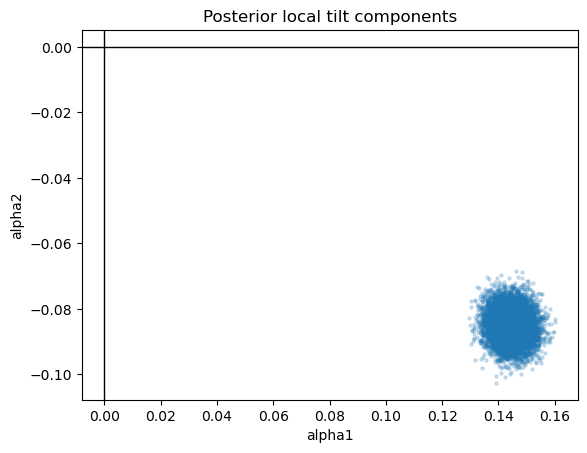

In [21]:
plt.scatter(alpha1_samples, alpha2_samples, s=5, alpha=0.2)
plt.axhline(0, color="k", lw=1)
plt.axvline(0, color="k", lw=1)
plt.xlabel("alpha1")
plt.ylabel("alpha2")
plt.title("Posterior local tilt components")
plt.show()

In [22]:
print("True dipole moment components:")
print(f"m_x_true = {m_vec_true[0]:.6e}")
print(f"m_y_true = {m_vec_true[1]:.6e}")
print(f"m_z_true = {m_vec_true[2]:.6e}")

print("\nPosterior mean dipole moment components:")
print(f"m_x_post = {m_x_samples.mean():.6e}")
print(f"m_y_post = {m_y_samples.mean():.6e}")
print(f"m_z_post = {m_z_samples.mean():.6e}")

True dipole moment components:
m_x_true = 4.436351e-17
m_y_true = -2.366054e-17
m_z_true = 2.957568e-16

Posterior mean dipole moment components:
m_x_post = 4.286343e-17
m_y_post = -2.518505e-17
m_z_post = 2.965266e-16


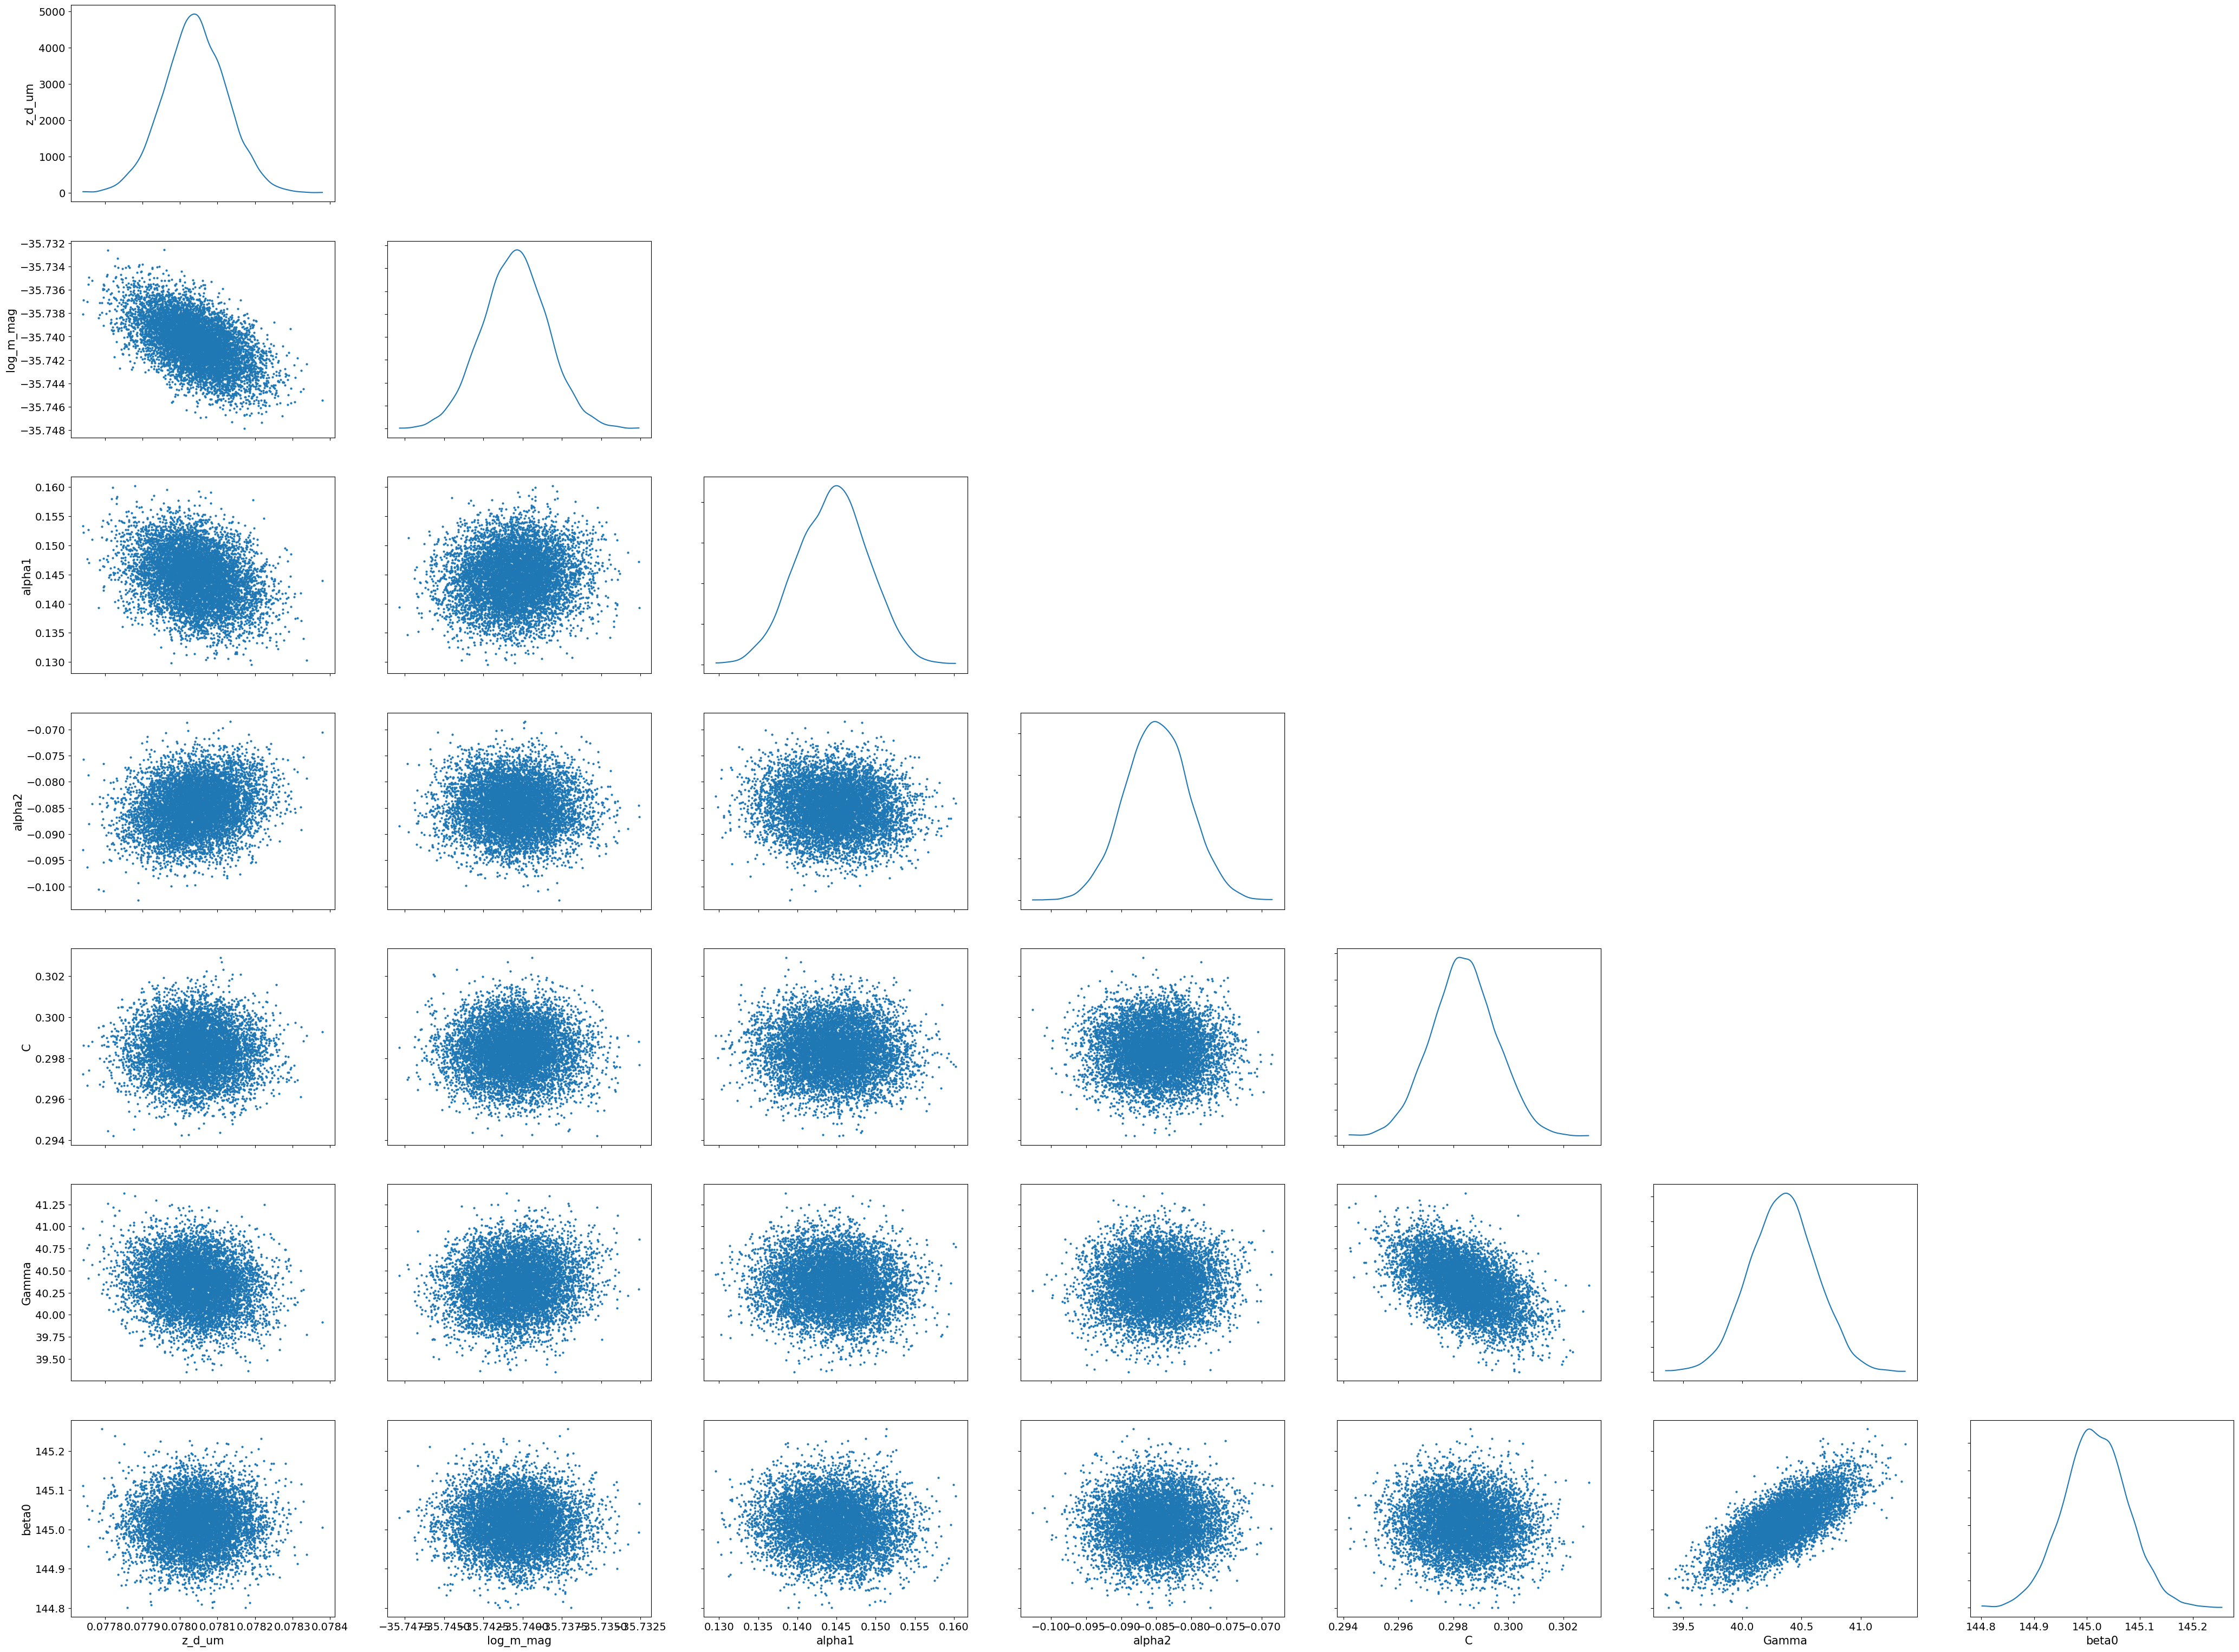

In [23]:
az.plot_pair(
    nv_samples,
    var_names=["z_d_um", "log_m_mag", "alpha1", "alpha2", "C", "Gamma", "beta0"],
    marginals=True
)
plt.show()

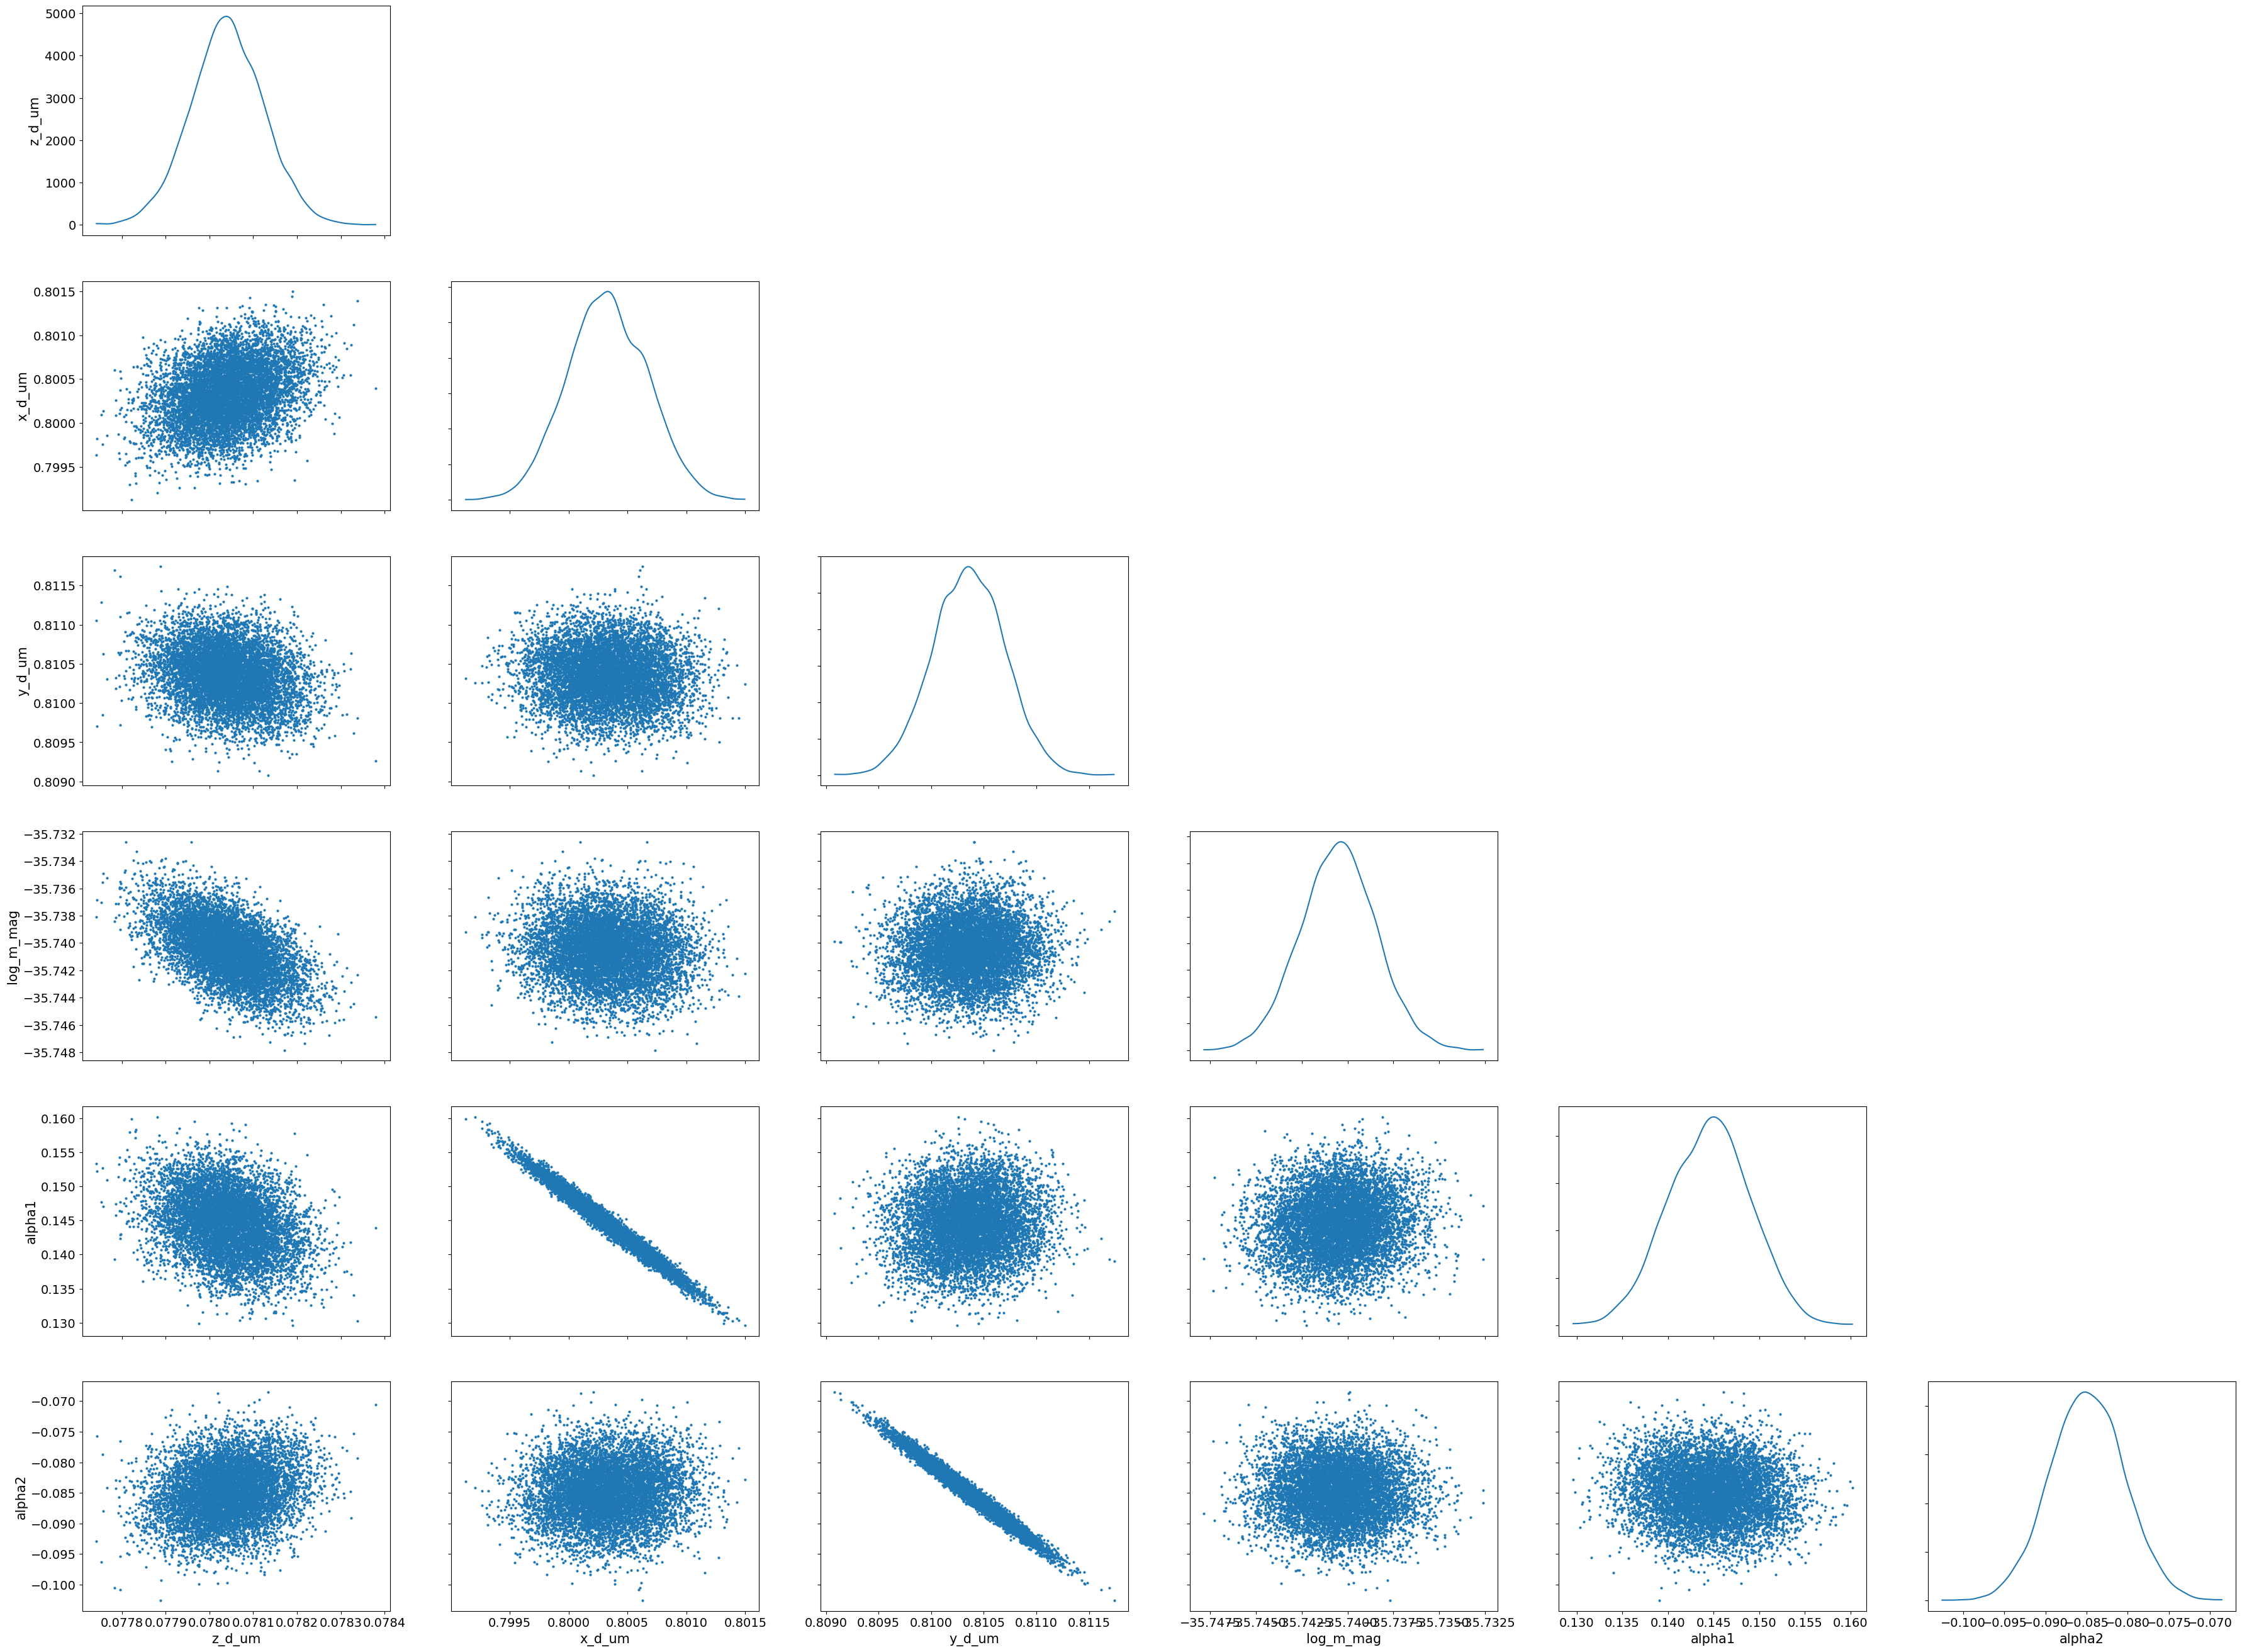

In [24]:
az.plot_pair(
    nv_samples,
    var_names=["z_d_um", "x_d_um", "y_d_um", "log_m_mag", "alpha1", "alpha2"],
    marginals=True
)
plt.show()

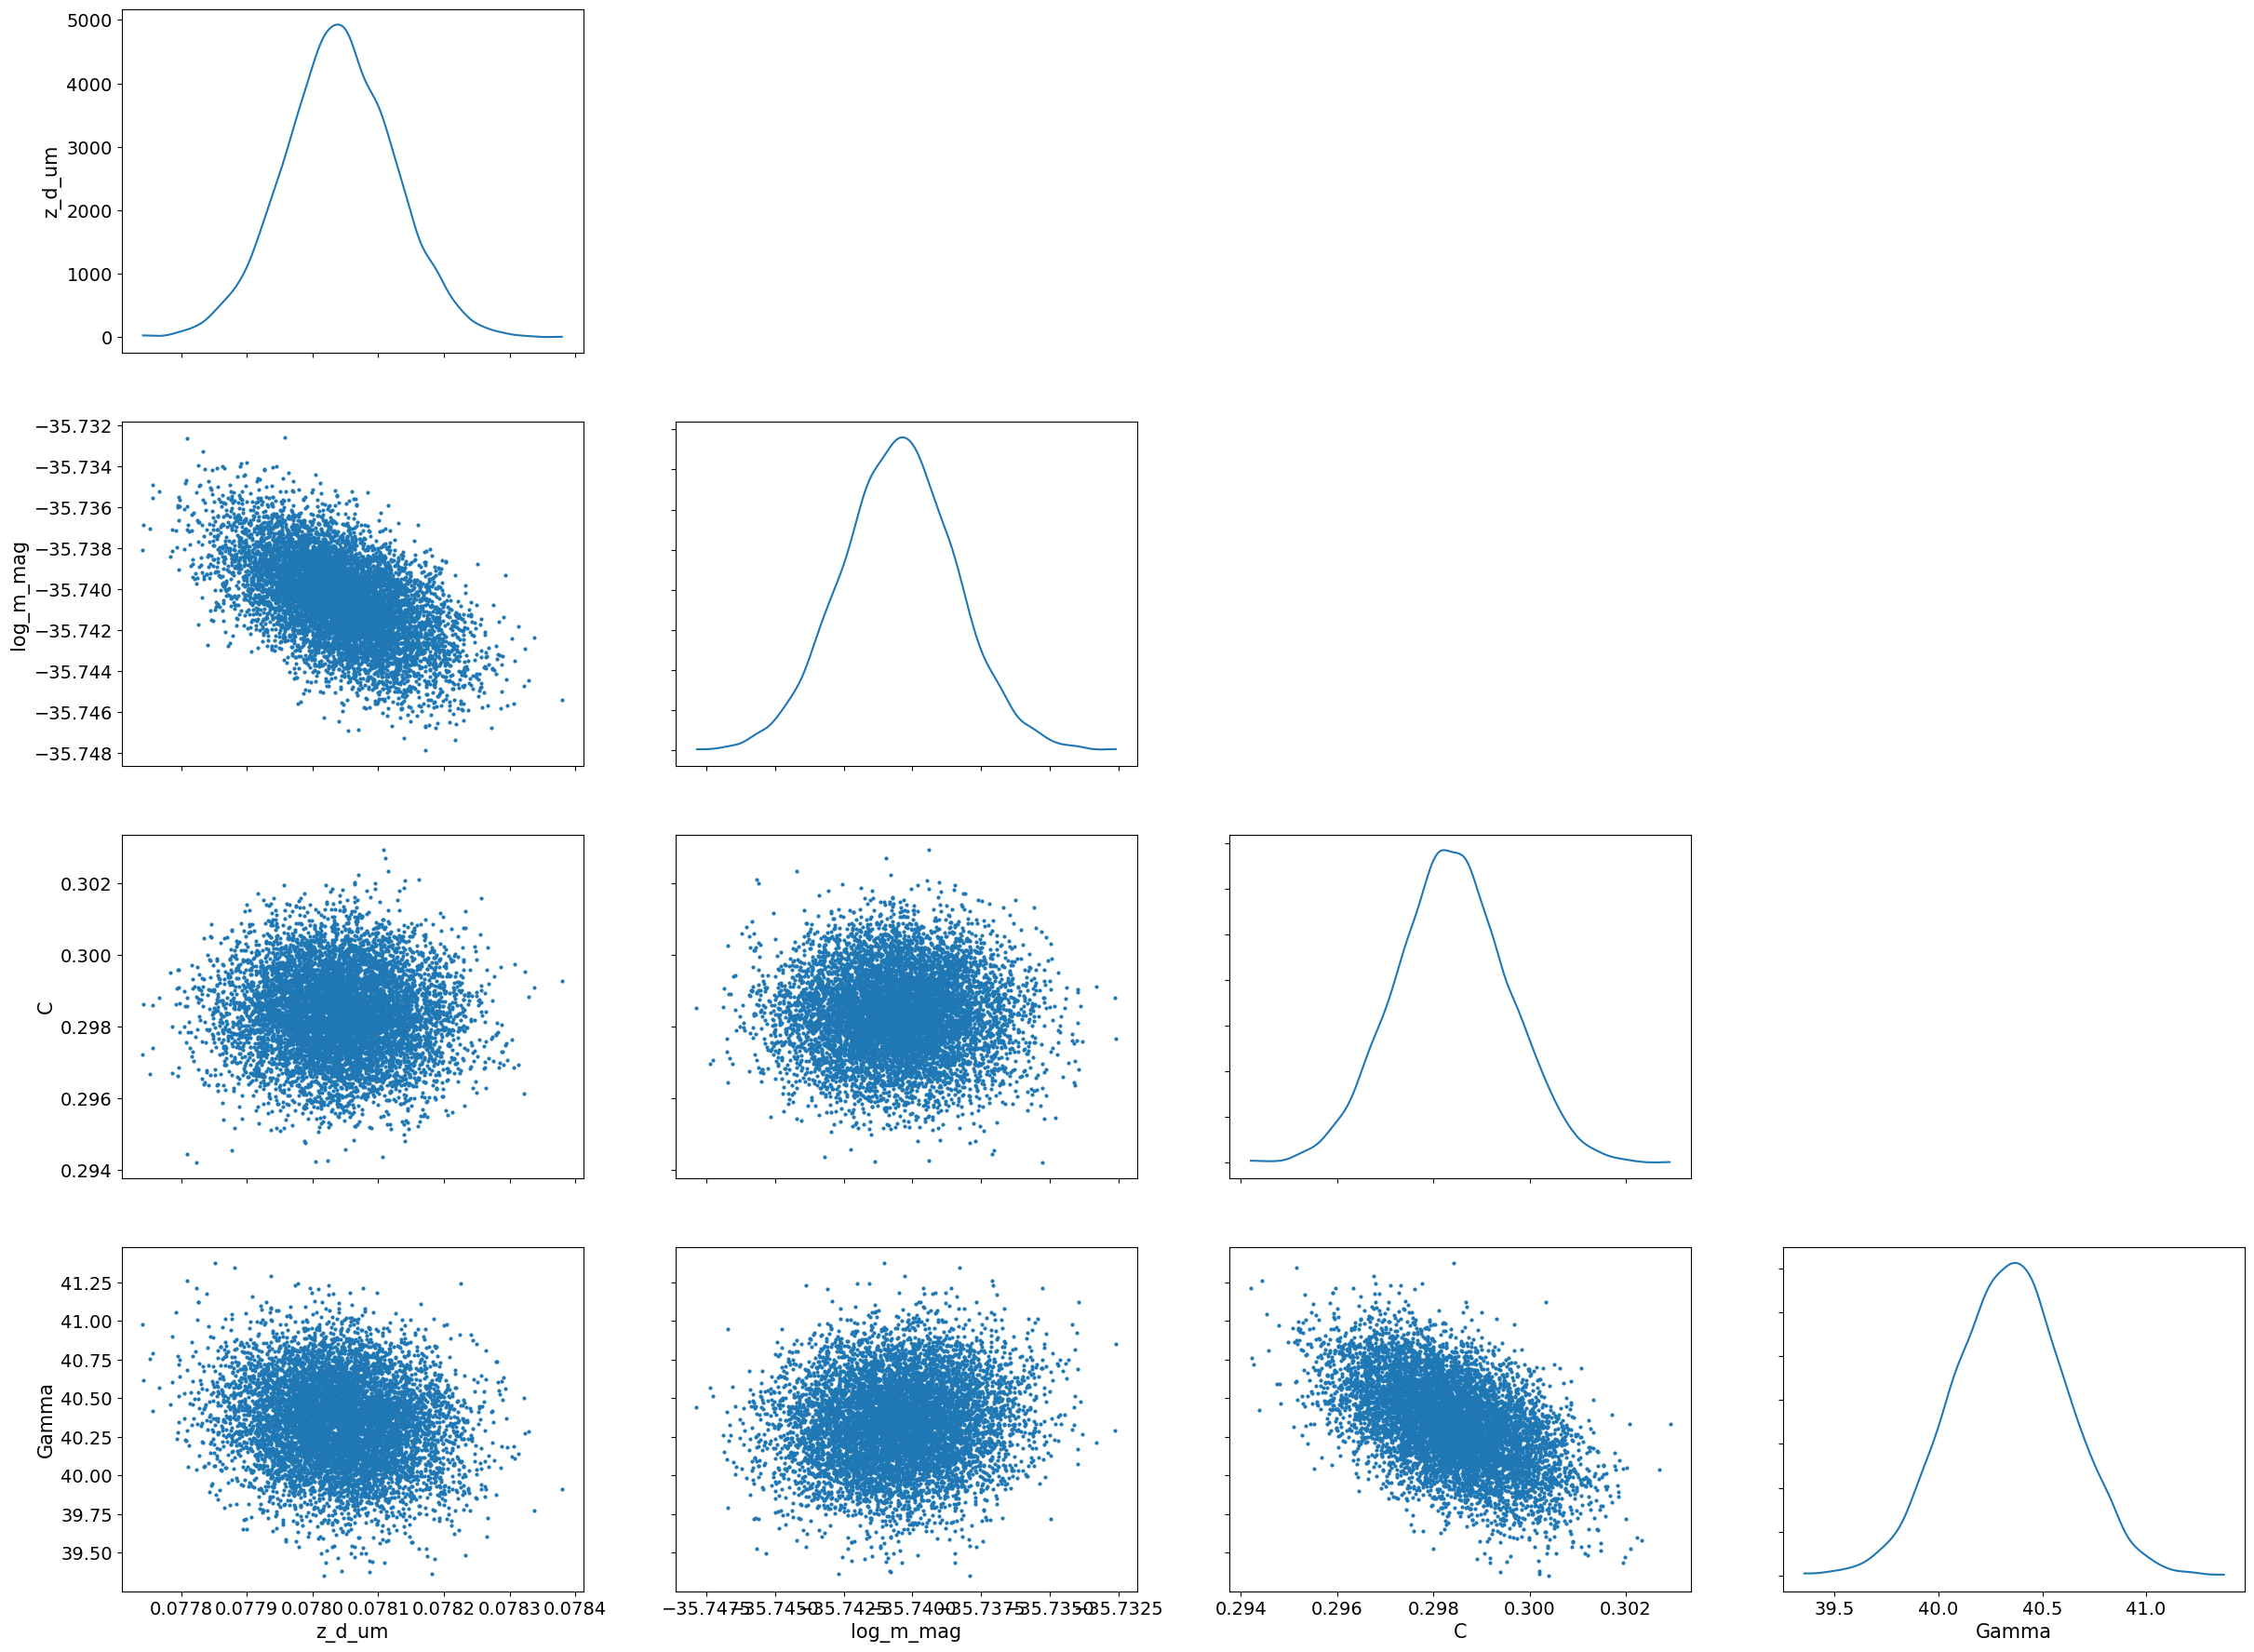

In [25]:
az.plot_pair(
    nv_samples,
    var_names=["z_d_um", "log_m_mag", "C", "Gamma"],
    marginals=True
)
plt.show()

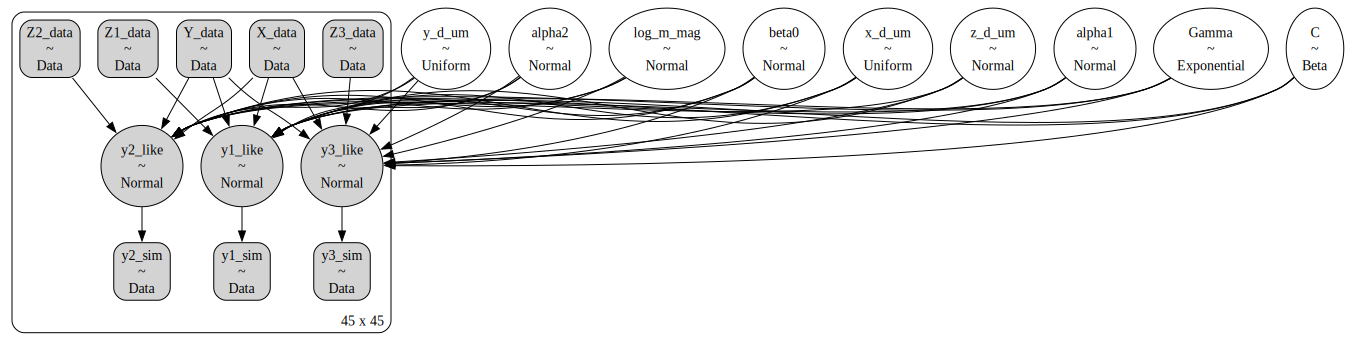

In [26]:
nv_model.to_graphviz()